<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FMLpr08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

from google.colab import files
uploaded = files.upload()


df = pd.read_csv("StudentsPerformance.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Libraries imported successfully!


Saving StudentsPerformance.csv to StudentsPerformance (3).csv
Dataset loaded successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Missing Values:
gender                         0
race/ethnicity                 0
parental le

In [13]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Hours_Studied', 'Attendance', 'Tutoring_Sessions', 'Final_Exam_Score', 'State']


In [14]:
required_columns = [
    "Hours_Studied",
    "Attendance",
    "Tutoring_Sessions",
    "Final_Exam_Score"
]

df = df[required_columns].dropna()

print("Selected Dataset:")
print(df.head())

print("\nShape after cleaning:", df.shape)

Selected Dataset:
   Hours_Studied  Attendance  Tutoring_Sessions  Final_Exam_Score
0              6    0.814267                  4         72.666667
1             19    0.990974                  4         82.333333
2             28    0.952636                  5         92.666667
3             14    0.951499                  2         49.333333
4             10    0.840608                  1         76.333333

Shape after cleaning: (1000, 4)


In [15]:
def create_state(hours):
    if hours < 10:
        return 0
    elif hours < 20:
        return 1
    else:
        return 2

df["State"] = df["Hours_Studied"].apply(create_state)

state_names = {
    0: "Low Study",
    1: "Medium Study",
    2: "High Study"
}

print(df.head())

   Hours_Studied  Attendance  Tutoring_Sessions  Final_Exam_Score  State
0              6    0.814267                  4         72.666667      0
1             19    0.990974                  4         82.333333      1
2             28    0.952636                  5         92.666667      2
3             14    0.951499                  2         49.333333      1
4             10    0.840608                  1         76.333333      1


In [17]:
actions = [
    "Increase Study Hours",
    "Maintain Study Hours",
    "Add Tutoring",
    "Improve Attendance"
]

print("Available Actions:")

for i, action in enumerate(actions):
    print(i, ":", action)


def calculate_reward(score):
    if score >= 80:
        return 10
    elif score >= 60:
        return 5
    elif score >= 40:
        return 1
    else:
        return -5

Available Actions:
0 : Increase Study Hours
1 : Maintain Study Hours
2 : Add Tutoring
3 : Improve Attendance


In [18]:
num_states = 3
num_actions = 4

Q = np.zeros((num_states, num_actions))

print("Initial Q-Table:")
print(Q)

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 1000

print("Q-Learning parameters:")
print("Learning Rate:", alpha)
print("Discount Factor:", gamma)
print("Episodes:", episodes)

Initial Q-Table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Q-Learning parameters:
Learning Rate: 0.1
Discount Factor: 0.9
Episodes: 1000


In [19]:
rewards_per_episode = []

for episode in range(episodes):


    student = df.sample(1).iloc[0]

    current_state = int(student["State"])
    current_score = student["Final_Exam_Score"]


    if random.random() < epsilon:
        action = random.randint(0, num_actions - 1)
    else:
        action = np.argmax(Q[current_state])


    reward = calculate_reward(current_score)


    if action == 0:
        next_state = min(current_state + 1, 2)

    elif action == 1:
        next_state = current_state

    elif action == 2:
        next_state = min(current_state + 1, 2)

    else:
        next_state = min(current_state + 1, 2)


    old_value = Q[current_state, action]

    best_next_value = np.max(Q[next_state])

    new_value = old_value + alpha * (
        reward + gamma * best_next_value - old_value
    )

    Q[current_state, action] = new_value

    rewards_per_episode.append(reward)


    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training completed successfully!")

Training completed successfully!


In [20]:
Q_table = pd.DataFrame(
    Q,
    index=["Low Study", "Medium Study", "High Study"],
    columns=actions
)

print("Trained Q-Table:")
display(Q_table.round(2))

Trained Q-Table:


,Increase Study Hours,Maintain Study Hours,Add Tutoring,Improve Attendance
Low Study,45.99,10.08,13.73,23.31
Medium Study,14.59,18.70,18.38,48.48
High Study,29.73,21.41,49.09,27.93


In [21]:
print("Best Study Strategy for Each State:\n")

for state in range(num_states):

    best_action = np.argmax(Q[state])

    print(
        state_names[state],
        "→",
        actions[best_action],
        "| Q-value:",
        round(Q[state, best_action], 2)
    )

Best Study Strategy for Each State:

Low Study → Increase Study Hours | Q-value: 45.99
Medium Study → Improve Attendance | Q-value: 48.48
High Study → Add Tutoring | Q-value: 49.09


In [22]:
def recommend_strategy(hours):

    state = create_state(hours)

    best_action = np.argmax(Q[state])

    print("Student Study Hours:", hours)
    print("Current State:", state_names[state])
    print("Recommended Strategy:", actions[best_action])
    print("Q-Value:", round(Q[state, best_action], 2))

recommend_strategy(8)

print("Student 1:")
recommend_strategy(5)

print("\nStudent 2:")
recommend_strategy(15)

print("\nStudent 3:")
recommend_strategy(25)

Student Study Hours: 8
Current State: Low Study
Recommended Strategy: Increase Study Hours
Q-Value: 45.99
Student 1:
Student Study Hours: 5
Current State: Low Study
Recommended Strategy: Increase Study Hours
Q-Value: 45.99

Student 2:
Student Study Hours: 15
Current State: Medium Study
Recommended Strategy: Improve Attendance
Q-Value: 48.48

Student 3:
Student Study Hours: 25
Current State: High Study
Recommended Strategy: Add Tutoring
Q-Value: 49.09


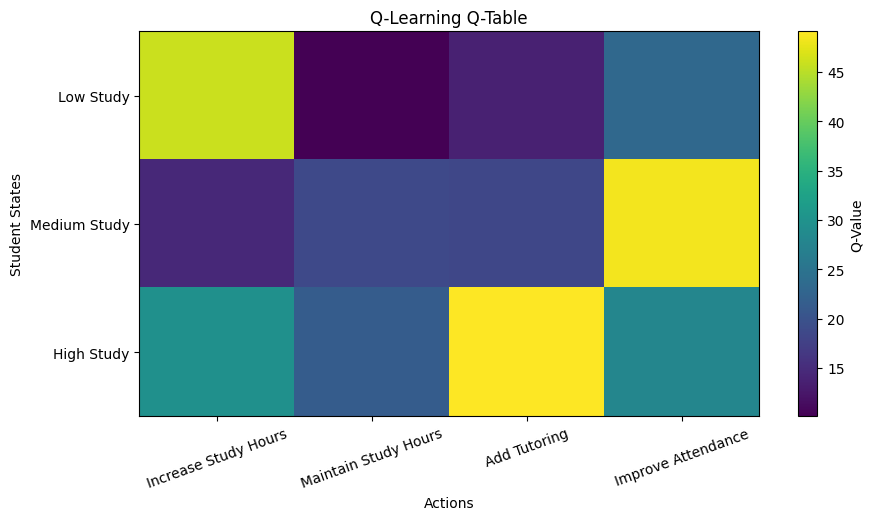

In [26]:
plt.figure(figsize=(10, 5))

plt.imshow(Q, aspect="auto")

plt.xticks(range(num_actions), actions, rotation=20)
plt.yticks(
    range(num_states),
    ["Low Study", "Medium Study", "High Study"]
)

plt.xlabel("Actions")
plt.ylabel("Student States")
plt.title("Q-Learning Q-Table")

plt.colorbar(label="Q-Value")
plt.show()



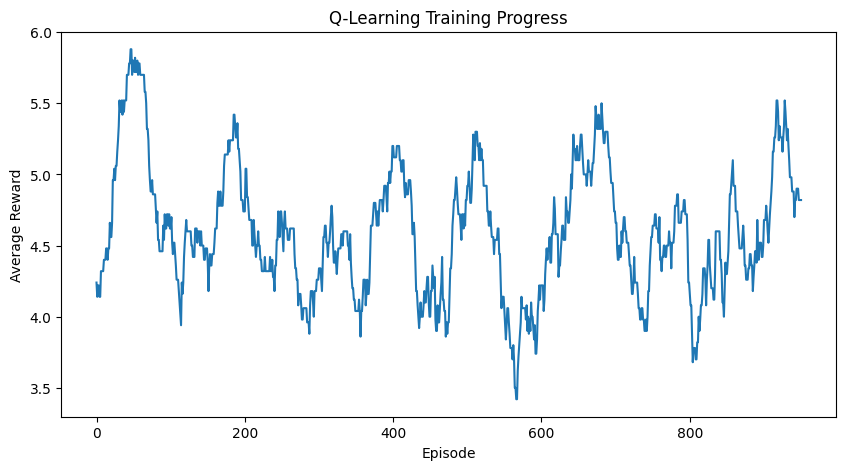

In [27]:
window = 50

moving_average = np.convolve(
    rewards_per_episode,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Training Progress")

plt.show()